In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Seoul Bike Sharing Demand - Regression

**Dataset:** Dua, D. and Graff, C. (2019). UCI Machine Learning Repository. Irvine, CA: University of California, School of Information and Computer Science.

**Source:** [data.seoul.go.kr](http://data.seoul.go.kr/) · South Korea Public Holidays: publicholidays.go.kr

**Goal:** Predict the number of rented bikes given weather + temporal features.  
function $f: \mathbb{R}^d \rightarrow \mathbb{R}$ that maps $d$ input features to a continuous target $y$ (bike count).

In [2]:
# Load data 
df = pd.read_csv(r"Data\seoul+bike+sharing+demand\SeoulBikeData.csv",
                 encoding="latin-1")

In [3]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
# extract temporal signals from Date
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df["month"] = df["Date"].dt.month
df["day_of_week"] = df["Date"].dt.dayofweek  # 0=Mon, 6=Sun
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Encode categorical columns as numeric
df["Holiday"] = (df["Holiday"] == "Holiday").astype(int)

# Filter out non-functioning days (system offline → bike count trivially 0)
df = df[df["Functioning Day"] == "Yes"].drop("Functioning Day", axis=1)

# One-hot encode Seasons (4 categories → 3 dummy columns to avoid collinearity)
df = pd.get_dummies(df, columns=["Seasons"], drop_first=True, dtype=int)

# Drop Date column 
df = df.drop("Date", axis=1)

# Clean column names
df.columns = [c.replace("(°C)", "").replace("(%)", "").replace("(cm)", "")
               .replace("(mm)", "").replace("(m/s)", "").replace("(10m)", "")
               .replace("(MJ/m2)", "").replace(" ", "_").strip("_").lower()
               for c in df.columns]
df = df.rename(columns={"rented_bike_count": "bike_count"})

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Features: {list(df.columns)}")

Dataset: 8465 rows × 17 columns
Features: ['bike_count', 'hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'holiday', 'month', 'day_of_week', 'is_weekend', 'seasons_spring', 'seasons_summer', 'seasons_winter']


In [5]:
df.head()

,bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,holiday,month,day_of_week,is_weekend,seasons_spring,seasons_summer,seasons_winter
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,12,4,0,0,0,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,12,4,0,0,0,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,12,4,0,0,0,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,12,4,0,0,0,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,12,4,0,0,0,1


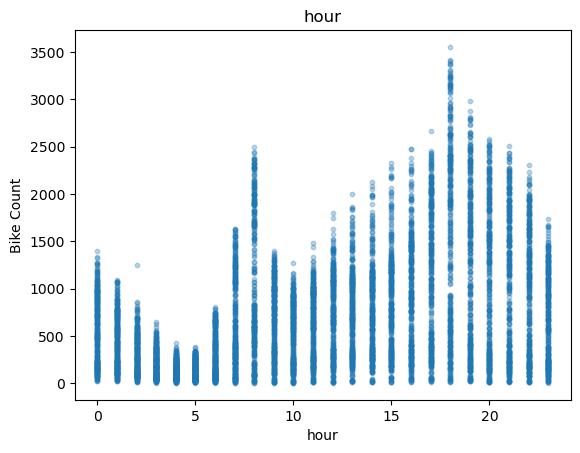

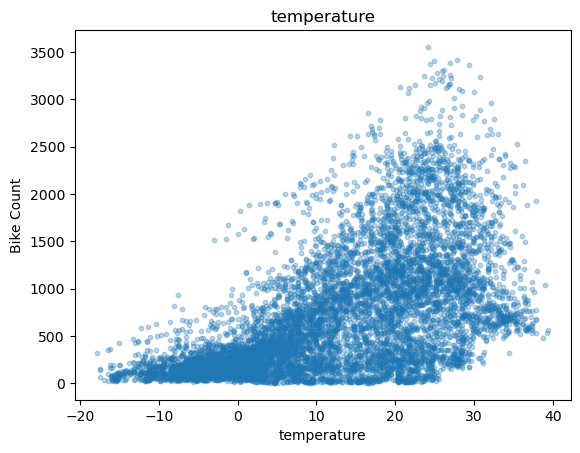

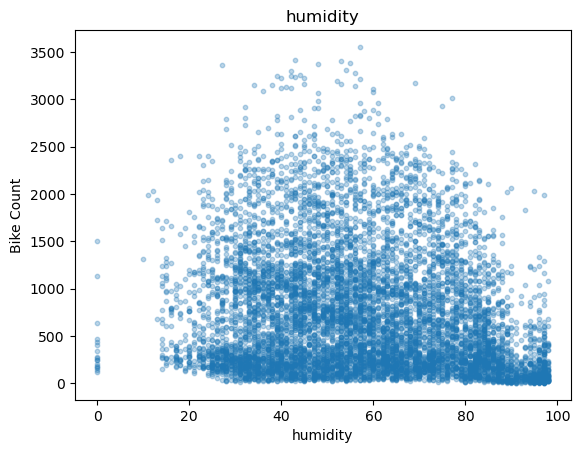

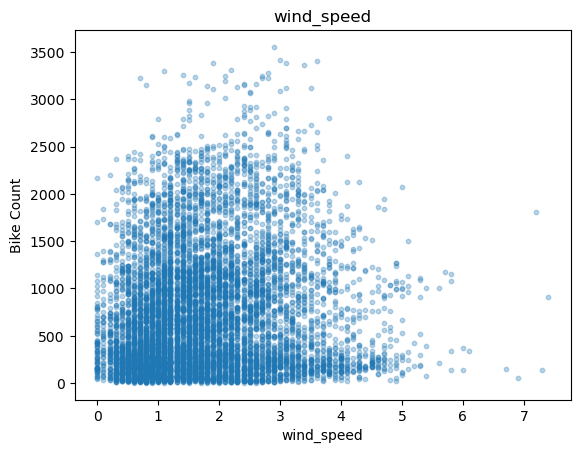

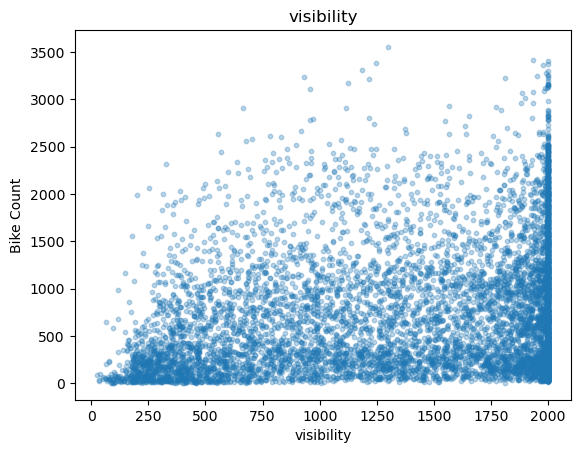

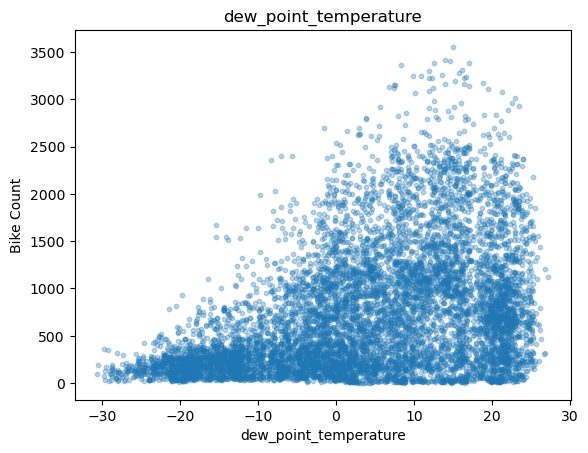

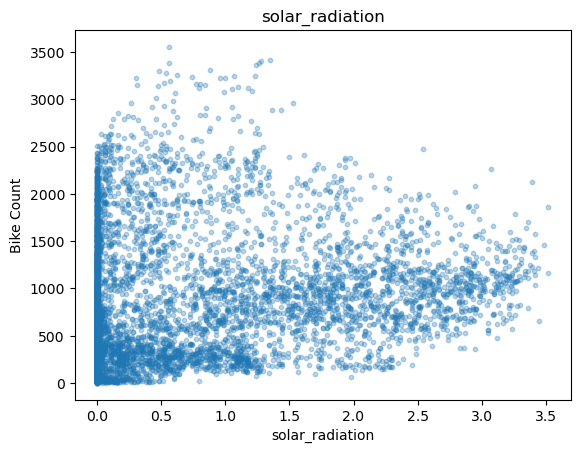

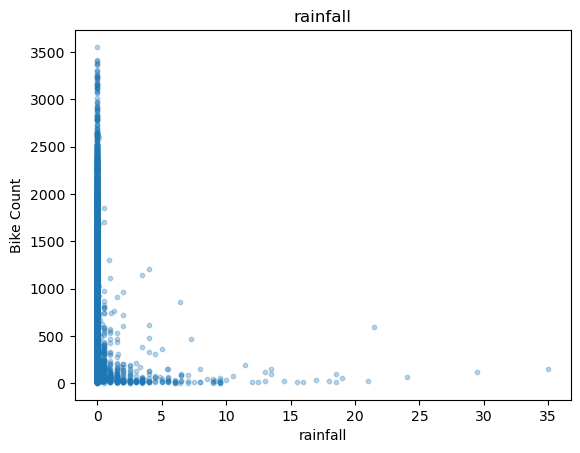

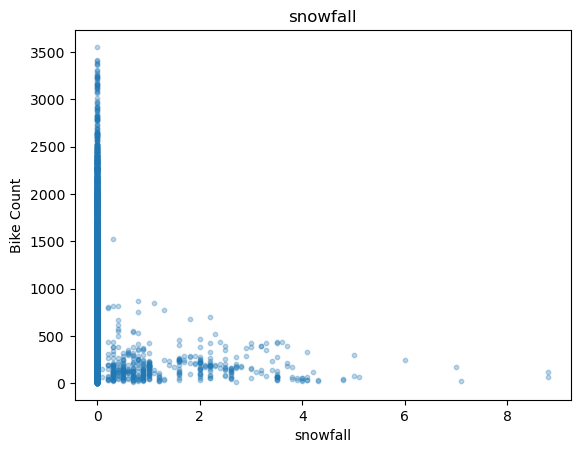

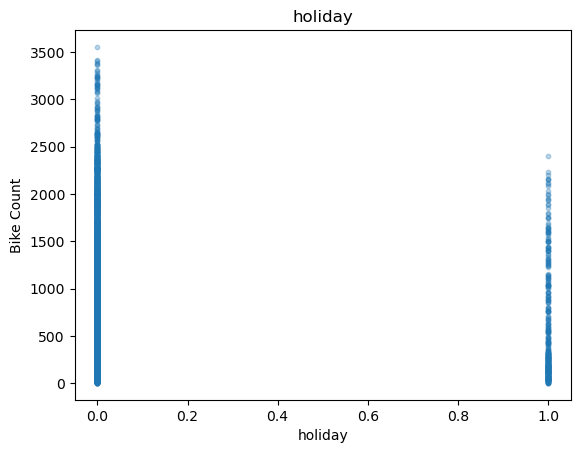

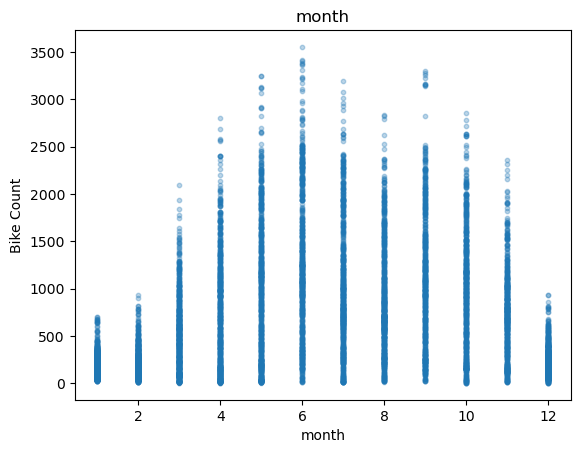

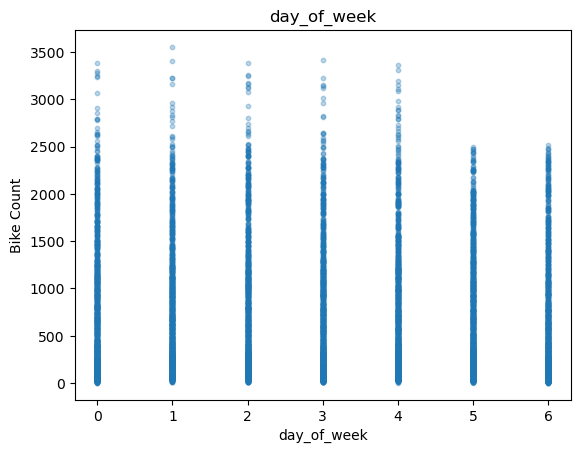

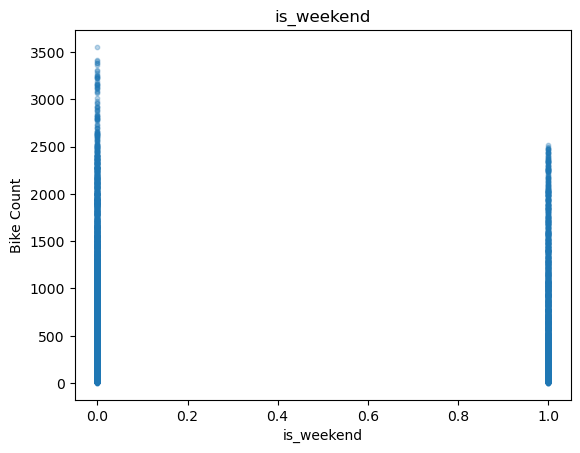

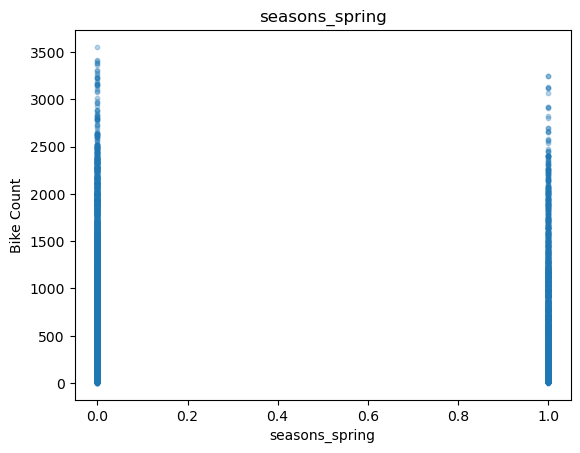

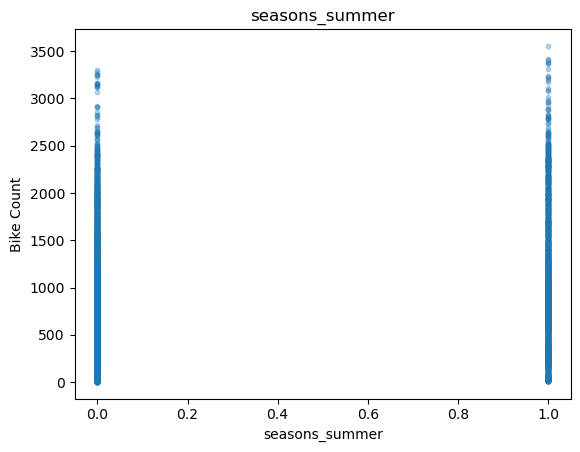

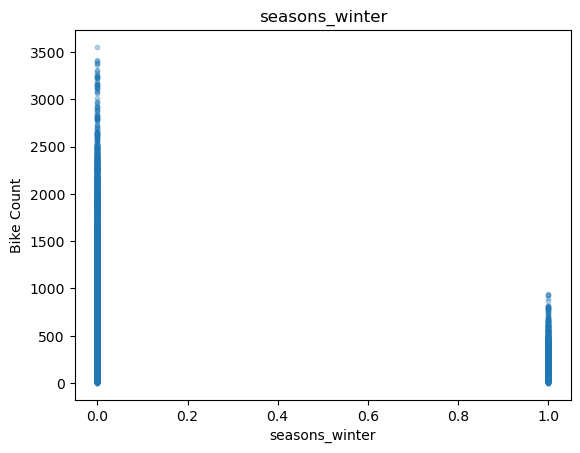

In [6]:
# Scatter each feature against bike_count to decide which features to keep
for label in df.columns[1:]:
    plt.scatter(df[label], df["bike_count"], alpha=0.3, s=10)
    plt.title(label)
    plt.ylabel("Bike Count")
    plt.xlabel(label)
    plt.show()

In [7]:
# Drop features with weak/no linear correlation or high collinearity
# visibility: clusters around a few values, weak linear signal for bike count
# dew_point_temperature: ~0.9 correlation with temperature (redundant — collinear)
df = df.drop(["visibility", "dew_point_temperature"], axis=1)

In [8]:
df.head()

,bike_count,hour,temperature,humidity,wind_speed,solar_radiation,rainfall,snowfall,holiday,month,day_of_week,is_weekend,seasons_spring,seasons_summer,seasons_winter
0,254,0,-5.2,37,2.2,0.0,0.0,0.0,0,12,4,0,0,0,1
1,204,1,-5.5,38,0.8,0.0,0.0,0.0,0,12,4,0,0,0,1
2,173,2,-6.0,39,1.0,0.0,0.0,0.0,0,12,4,0,0,0,1
3,107,3,-6.2,40,0.9,0.0,0.0,0.0,0,12,4,0,0,0,1
4,78,4,-6.0,36,2.3,0.0,0.0,0.0,0,12,4,0,0,0,1


## Train / Validation / Test Split

| Set | Fraction | Purpose |
|-----|----------|---------|
| Train | 60% | Fit model parameters |
| Validation | 20% | Tune hyperparameters, monitor overfitting |
| Test | 20% | Final unbiased evaluation |


In [9]:
train, val, test = np.split(df.sample(frac=1, random_state=SEED).reset_index(drop=True),
                           [int(0.6 * len(df)), int(0.8 * len(df))])

c:\Users\USER\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [10]:
def get_xy(dataframe, y_label, x_labels=None):
    dataframe = dataframe.copy()
    if x_labels is None:
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    elif len(x_labels) == 1:
        X = dataframe[x_labels[0]].values.reshape(-1, 1)
    else:
        X = dataframe[x_labels].values
    y = dataframe[y_label].values.reshape(-1, 1)
    return np.hstack((X, y)), X, y

In [11]:
_, X_train_temp, y_train_temp = get_xy(train, "bike_count", x_labels=["temperature"])
_, X_val_temp, y_val_temp = get_xy(val, "bike_count", x_labels=["temperature"])
_, X_test_temp, y_test_temp = get_xy(test, "bike_count", x_labels=["temperature"])

## Linear Regression (All Features)

All remaining features (hour, temperature, humidity, wind speed, solar radiation, rainfall, snowfall, month, day-of-week, is_weekend, holiday, and season dummies) as inputs:

$$\hat{y} = \beta_0 + \sum_{j=1}^{d} \beta_j \cdot x_j = \mathbf{X}\boldsymbol{\beta}$$

OLS finds the closed-form solution: $\boldsymbol{\hat{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$

In [12]:
_, X_train_all, y_train_all = get_xy(train, "bike_count", x_labels=df.columns[1:])
_, X_val_all, y_val_all = get_xy(val, "bike_count", x_labels=df.columns[1:])
_, X_test_all, y_test_all = get_xy(test, "bike_count", x_labels=df.columns[1:])

In [13]:
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
all_reg.score(X_test_all,y_test_all)

0.5531127765443786

## Multi-Feature Deep Neural Net
All $d$ features as input: $\mathbf{x} \in \mathbb{R}^d$.

$$\hat{y} = f_{\theta}(\mathbf{x}) \quad \text{where } \theta = \{W^{(l)}, b^{(l)}\}_{l=1}^{4}$$

In [15]:
n_features = X_train_all.shape[1]
all_normalizer = tf.keras.layers.Normalization(input_shape=(n_features,), axis=-1)
all_normalizer.adapt(X_train_all)

all_nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
all_nn_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001),
                     loss="mean_squared_error")

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# EarlyStopping: stop training when val_loss hasn't improved for 20 epochs
# restore_best_weights: revert to the epoch with lowest val_loss
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

history = all_nn_model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val_all, y_val_all),
    verbose=0, epochs=300,
    callbacks=[early_stop]
)

In [17]:
# Save NN checkpoint and print final validation log line
import hashlib

all_nn_model.save("nn_bike_model.keras")
with open("nn_bike_model.keras", "rb") as f:
    nn_sha = hashlib.sha256(f.read()).hexdigest()[:12]

best_epoch = int(early_stop.best_epoch) + 1
total_epochs = len(history.history["loss"])
best_val_loss = min(history.history["val_loss"])
final_train_loss = history.history["loss"][early_stop.best_epoch]

print(f"Checkpoint: nn_bike_model.keras | SHA-256: {nn_sha}")
print(f"Stopped at epoch {total_epochs}/{300}, best epoch: {best_epoch}")
print(f"Best val_loss (MSE): {best_val_loss:.2f} | train_loss (MSE): {final_train_loss:.2f}")
print(f"Overfitting gap: {best_val_loss - final_train_loss:.2f}")

Checkpoint: nn_bike_model.keras | SHA-256: 5db076af19c9
Stopped at epoch 300/300, best epoch: 296
Best val_loss (MSE): 34731.52 | train_loss (MSE): 51259.13
Overfitting gap: -16527.61


In [18]:
def plot_loss(history):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

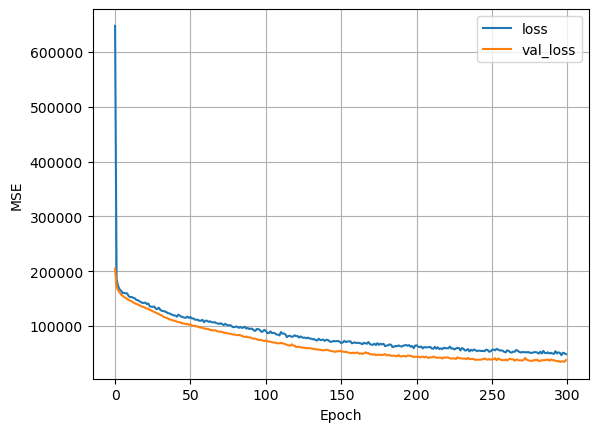

In [19]:
plot_loss(history)

## Gradient Boosting Regressor

An ensemble of **decision trees** trained sequentially - each new tree corrects the residuals of the previous ones:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

where $h_m$ is a shallow tree fit to the **negative gradient** of the loss:

$$h_m = \arg\min_h \sum_{i=1}^{n} \left[ -\frac{\partial \mathcal{L}(y_i, F_{m-1}(\mathbf{x}_i))}{\partial F_{m-1}(\mathbf{x}_i)} - h(\mathbf{x}_i) \right]^2$$

**Hyperparameters:** 200 trees, max depth 5, learning rate 0.1.

In [20]:
# Train gradient boosting on the same multi-feature split
gbr = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=SEED
)
gbr.fit(X_train_all, y_train_all.ravel())
print(f"GBR Train R²: {gbr.score(X_train_all, y_train_all.ravel()):.4f}")
print(f"GBR Test R²:  {gbr.score(X_test_all, y_test_all.ravel()):.4f}")

GBR Train R²: 0.9727
GBR Test R²:  0.9374


In [21]:
import hashlib
import joblib

# ----- Validation Log -----
print("=== Validation Log (GBR) ===")

for i, y_pred in enumerate(gbr.staged_predict(X_test_all)):
    if (i+1) % 50 == 0:   # print every 50 trees
        mse = mean_squared_error(y_test_all, y_pred)
        print(f"Tree {i+1}: Validation MSE = {mse:.2f}")

# Compute MSE for all stages
val_mses = [mean_squared_error(y_test_all, y_pred)
            for y_pred in gbr.staged_predict(X_test_all)]
train_mses = [mean_squared_error(y_train_all, y_pred)
              for y_pred in gbr.staged_predict(X_train_all)]

# Find best tree (lowest validation MSE)
best_tree = val_mses.index(min(val_mses)) + 1
best_val_mse = val_mses[best_tree-1]
train_mse_at_best = train_mses[best_tree-1]
overfit_gap = best_val_mse - train_mse_at_best

# Save model checkpoint
joblib.dump(gbr, "gbr_bike_model.joblib")
with open("gbr_bike_model.joblib", "rb") as f:
    gbr_sha = hashlib.sha256(f.read()).hexdigest()[:12]

# Final validation summary
print("\n=== Final GBR Validation Summary ===")
print(f"Checkpoint: gbr_bike_model.joblib | SHA-256: {gbr_sha}")
print(f"Best tree: {best_tree}/{gbr.n_estimators}")
print(f"Best validation MSE: {best_val_mse:.2f}")
print(f"Training MSE at best tree: {train_mse_at_best:.2f}")
print(f"Overfitting gap (val - train): {overfit_gap:.2f}")

=== Validation Log (GBR) ===
Tree 50: Validation MSE = 36731.51
Tree 100: Validation MSE = 28689.36
Tree 150: Validation MSE = 26673.02
Tree 200: Validation MSE = 25771.78

=== Final GBR Validation Summary ===
Checkpoint: gbr_bike_model.joblib | SHA-256: 2b366f121c92
Best tree: 199/200
Best validation MSE: 25761.79
Training MSE at best tree: 11366.45
Overfitting gap (val - train): 14395.34


In [22]:
def plot_gbr_loss(train_mses, val_mses):
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_mses)+1), train_mses, label="Train MSE")
    plt.plot(range(1, len(val_mses)+1), val_mses, label="Validation MSE")
    plt.xlabel("Number of Trees")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

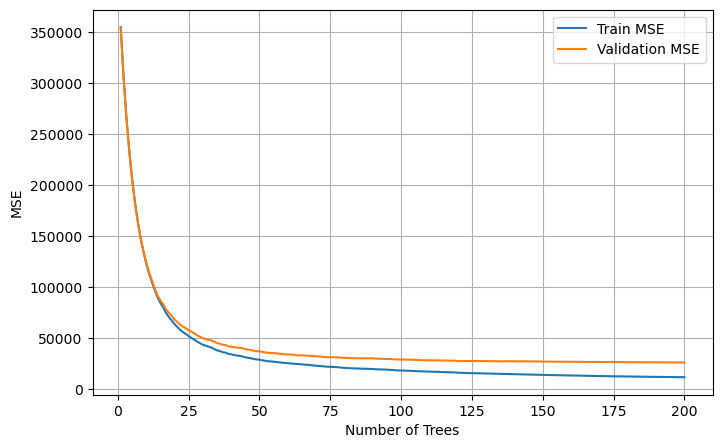

In [23]:
plot_gbr_loss(train_mses, val_mses)

In [24]:
y_pred_lr = all_reg.predict(X_test_all)
y_pred_nn = all_nn_model.predict(X_test_all)
y_pred_gbr = gbr.predict(X_test_all).reshape(-1, 1)

print(f"Linear Regression R²:       {r2_score(y_test_all, y_pred_lr):.4f}")
print(f"Neural Net R²:              {r2_score(y_test_all, y_pred_nn):.4f}")
print(f"Gradient Boosting R²:       {r2_score(y_test_all, y_pred_gbr):.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Linear Regression R²:       0.5531
Neural Net R²:              0.9233
Gradient Boosting R²:       0.9374


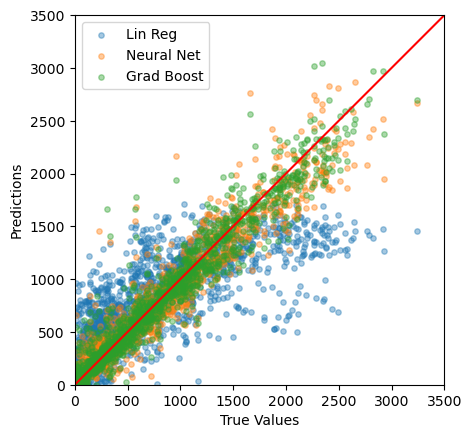

In [25]:
ax = plt.axes(aspect="equal")
plt.scatter(y_test_all, y_pred_lr, label="Lin Reg", alpha=0.4, s=15)
plt.scatter(y_test_all, y_pred_nn, label="Neural Net", alpha=0.4, s=15)
plt.scatter(y_test_all, y_pred_gbr, label="Grad Boost", alpha=0.4, s=15)
plt.xlabel("True Values")
plt.ylabel("Predictions")
lims = [0, 3500]
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
plt.plot(lims, lims, c="red")
plt.show()

## Error Analysis (Residuals)

$$e_i = y_i - \hat{y}_i$$

In [26]:
residuals_lr = y_test_all.flatten() - y_pred_lr.flatten()
residuals_nn = y_test_all.flatten() - y_pred_nn.flatten()
residuals_gbr = y_test_all.flatten() - y_pred_gbr.flatten()

# 5 worst GBR predictions
worst_idx = np.argsort(np.abs(residuals_gbr))[-5:]
print("Worst GBR predictions (index | true | predicted | error):")
for i in worst_idx:
    print(f"  {i:>4d} | {y_test_all[i,0]:>7.1f} | {y_pred_gbr[i,0]:>7.1f} | {residuals_gbr[i]:>+8.1f}")

Worst GBR predictions (index | true | predicted | error):
   180 |   959.0 |  1941.8 |   -982.8
  1110 |   336.0 |  1404.1 |  -1068.1
    67 |   567.0 |  1663.9 |  -1096.9
  1625 |   582.0 |  1781.3 |  -1199.3
   347 |   306.0 |  1659.9 |  -1353.9


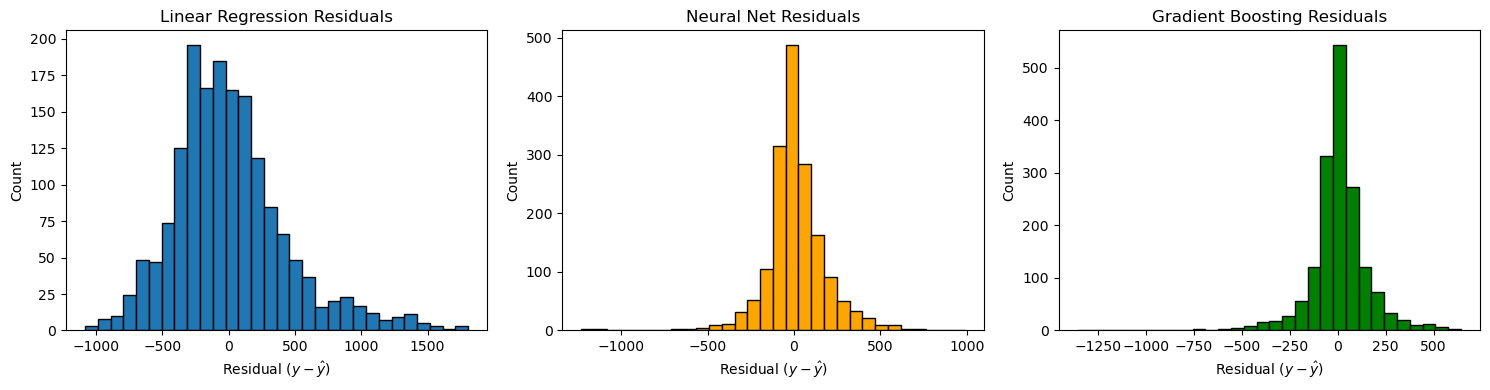

In [27]:
# Histogram of residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuals_lr, bins=30, edgecolor="black")
axes[0].set_title("Linear Regression Residuals")
axes[0].set_xlabel("Residual $(y - \hat{y})$")
axes[0].set_ylabel("Count")

axes[1].hist(residuals_nn, bins=30, edgecolor="black", color="orange")
axes[1].set_title("Neural Net Residuals")
axes[1].set_xlabel("Residual $(y - \hat{y})$")
axes[1].set_ylabel("Count")

axes[2].hist(residuals_gbr, bins=30, edgecolor="black", color="green")
axes[2].set_title("Gradient Boosting Residuals")
axes[2].set_xlabel("Residual $(y - \hat{y})$")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

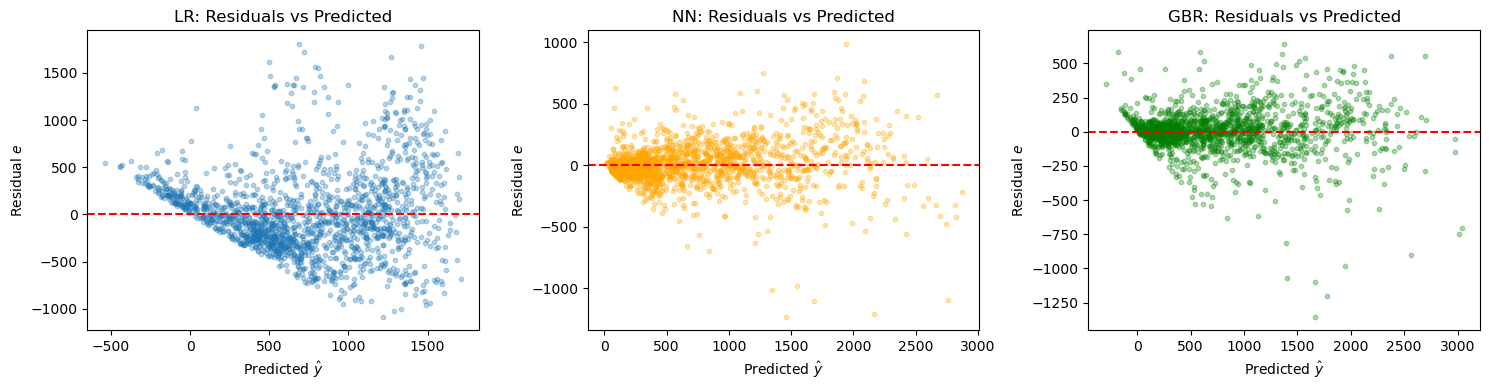

In [28]:
# Residuals vs Predicted - checks for heteroscedasticity
# Ideal: random scatter around the red y=0 line
# Bad sign: cone/fan shape = variance grows with predicted value
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=10)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_title("LR: Residuals vs Predicted")
axes[0].set_xlabel("Predicted $\hat{y}$")
axes[0].set_ylabel("Residual $e$")

axes[1].scatter(y_pred_nn, residuals_nn, alpha=0.3, s=10, color="orange")
axes[1].axhline(y=0, color="red", linestyle="--")
axes[1].set_title("NN: Residuals vs Predicted")
axes[1].set_xlabel("Predicted $\hat{y}$")
axes[1].set_ylabel("Residual $e$")

axes[2].scatter(y_pred_gbr, residuals_gbr, alpha=0.3, s=10, color="green")
axes[2].axhline(y=0, color="red", linestyle="--")
axes[2].set_title("GBR: Residuals vs Predicted")
axes[2].set_xlabel("Predicted $\hat{y}$")
axes[2].set_ylabel("Residual $e$")

plt.tight_layout()
plt.show()

## Final Validation Summary

| Metric | Formula |
|--------|---------|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ 
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ 
| **R²** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$

In [29]:
print("=== Final Test Set Metrics ===")
print(f"{'Metric':<12} {'Lin Reg':>10} {'Neural Net':>12} {'Grad Boost':>12}")
print("-" * 50)
print(f"{'MSE':<12} {mean_squared_error(y_test_all, y_pred_lr):>10.2f} {mean_squared_error(y_test_all, y_pred_nn):>12.2f} {mean_squared_error(y_test_all, y_pred_gbr):>12.2f}")
print(f"{'MAE':<12} {mean_absolute_error(y_test_all, y_pred_lr):>10.2f} {mean_absolute_error(y_test_all, y_pred_nn):>12.2f} {mean_absolute_error(y_test_all, y_pred_gbr):>12.2f}")
print(f"{'R2':<12} {r2_score(y_test_all, y_pred_lr):>10.4f} {r2_score(y_test_all, y_pred_nn):>12.4f} {r2_score(y_test_all, y_pred_gbr):>12.4f}")

=== Final Test Set Metrics ===
Metric          Lin Reg   Neural Net   Grad Boost
--------------------------------------------------
MSE           184069.72     31572.33     25771.78
MAE              321.08       118.33       100.22
R2               0.5531       0.9233       0.9374


## Conclusion

**Linear Regression**
- Model often makes large mistakes
- Errors up to 1500+ bikes according to residual analysis
- Only around 55% of variance explained (R² ≈ 0.55)
- Struggled because bike demand is non-linear - a straight line can't capture patterns like "demand peaks at 25°C then drops"

**Neural Network**
- Learned non-linear patterns that linear regression missed
- Residuals tighter and more centered around zero
- Still made errors of sometimes around 500+ bikes on unusual days (holidays, extreme weather)

**Gradient Boosting**
- Best performing model overall
- Smallest residuals and highest R² score
- Handled the mix of weather + time + season features naturally without needing normalization
- Even gradient boosting struggled on peak demand hours- those extreme values are hard to predict from weather alone

Overall, the results suggest that tree-based ensemble models are more suitable for this dataset, as they can capture nonlinear interactions between weather and temporal features without extensive preprocessing.